# W09-S01 — Trayectorias LSPB

**Asignatura:** IMT-342 Robótica  
**Gestión:** II-2026  
**Docente:** Bernardo Quiroga Turdera  

**Integrantes:**  
- Roberth Williams Ruiz Condori  
- Mario Alberto Nina Gallo  

**Fuente oficial:** `w09_s01_lspb_hoja_trabajo.pdf`

## Ejercicio 1 — Factibilidad del Perfil LSPB

Se desea planificar un movimiento articular con:

$$
q_i = 0,
\qquad
q_f = 2\ \text{rad},
\qquad
t_f = 3\ \text{s},
\qquad
\ddot{q}_c = 1\ \text{rad/s}^2.
$$

Calcule la aceleración mínima requerida:

$$
|\ddot{q}_c|_{\min}
=
\frac{4|q_f-q_i|}{t_f^2}
$$

y determine si es factible construir un perfil trapezoidal con la aceleración dada.

### Desarrollo

Para que un perfil LSPB trapezoidal sea factible, la magnitud de la aceleración debe cumplir:

$$
|\ddot{q}_c|
\geq
|\ddot{q}_c|_{\min}
$$

donde:

$$
|\ddot{q}_c|_{\min}
=
\frac{4|q_f-q_i|}{t_f^2}.
$$

Sustituyendo los datos:

$$
|\ddot{q}_c|_{\min}
=
\frac{4|2-0|}{3^2}
$$

$$
|\ddot{q}_c|_{\min}
=
\frac{8}{9}
$$

Por tanto:

$$
\boxed{
|\ddot{q}_c|_{\min}
=
\frac{8}{9}
\approx
0.889\ \text{rad/s}^2
}
$$

La aceleración disponible es:

$$
|\ddot{q}_c|
=
1\ \text{rad/s}^2.
$$

Comparando:

$$
1 >
\frac{8}{9}.
$$

Entonces se cumple la condición de factibilidad:

$$
\boxed{
|\ddot{q}_c|
>
|\ddot{q}_c|_{\min}
}
$$

Por lo tanto, **sí es factible construir el perfil trapezoidal LSPB** con los parámetros dados.

## Ejercicio 2 — Tiempo de Mezcla

Calcule el tiempo de aceleración $t_c$ utilizando:

$$
t_c=
\frac{t_f}{2}
-
\frac{1}{2}
\sqrt{
t_f^2-
\frac{4(q_f-q_i)}{\ddot q_c}
}.
$$

### Desarrollo

La expresión para el tiempo de mezcla es:

$$
t_c=
\frac{t_f}{2}
-
\frac{1}{2}
\sqrt{
t_f^2-
\frac{4(q_f-q_i)}{\ddot q_c}
}
$$

Sustituyendo:

$$
t_c=
\frac{3}{2}
-
\frac{1}{2}
\sqrt{
3^2-
\frac{4(2-0)}{1}
}
$$

$$
t_c=
\frac{3}{2}
-
\frac{1}{2}
\sqrt{9-8}
$$

$$
t_c=
\frac{3}{2}
-
\frac{1}{2}
$$

Por tanto:

$$
\boxed{
t_c=1\ \text{s}
}
$$

El perfil permanece en la fase de aceleración durante $1$ segundo antes de alcanzar la velocidad de crucero.

## Ejercicio 3 — Velocidad de Crucero

Calcule la velocidad de crucero utilizando:

$$
\dot q_c=\ddot q_c\,t_c.
$$

### Desarrollo

La velocidad de crucero del perfil LSPB se obtiene mediante:

$$
\dot q_c=\ddot q_c\,t_c
$$

Del ejercicio anterior:

$$
t_c=1\ \text{s}
$$

y la aceleración dada es:

$$
\ddot q_c=1\ \text{rad/s}^2.
$$

Sustituyendo:

$$
\dot q_c
=
(1\ \text{rad/s}^2)(1\ \text{s})
$$

Por tanto:

$$
\boxed{
\dot q_c=1\ \text{rad/s}
}
$$

Esto significa que, una vez finalizada la fase de aceleración, la articulación mantiene una velocidad constante de:

$$
1\ \text{rad/s}
$$

durante la fase de velocidad de crucero.

## Ejercicio 4 — Fases del Perfil LSPB

Identifique en los gráficos de posición, velocidad y aceleración las zonas correspondientes a:

1. Aceleración.
2. Velocidad constante.
3. Desaceleración.

### Desarrollo

De los ejercicios anteriores se obtuvo:

$$
t_c=1\ \text{s},
\qquad
t_f=3\ \text{s}.
$$

El inicio de la desaceleración ocurre en:

$$
t_f-t_c=3-1=2\ \text{s}.
$$

Por tanto, las tres fases del perfil LSPB son:

### 1. Aceleración

$$
\boxed{0\leq t\leq1\ \text{s}}
$$

Durante esta fase:

$$
\ddot q(t)=1\ \text{rad/s}^2
$$

$$
\dot q(t)=t
$$

$$
q(t)=\frac{1}{2}t^2
$$

La velocidad aumenta linealmente desde $0$ hasta $1\ \text{rad/s}$.

---

### 2. Velocidad constante

$$
\boxed{1<t\leq2\ \text{s}}
$$

Durante esta fase:

$$
\ddot q(t)=0
$$

$$
\dot q(t)=1\ \text{rad/s}
$$

$$
q(t)=t-\frac{1}{2}
$$

La articulación mantiene la velocidad de crucero calculada anteriormente.

---

### 3. Desaceleración

$$
\boxed{2<t\leq3\ \text{s}}
$$

Durante esta fase:

$$
\ddot q(t)=-1\ \text{rad/s}^2
$$

$$
\dot q(t)=3-t
$$

$$
q(t)=2-\frac{1}{2}(3-t)^2
$$

La velocidad disminuye linealmente desde $1\ \text{rad/s}$ hasta llegar a cero en $t=3\ \text{s}$.

Por tanto:

$$
\boxed{
\begin{array}{c|c}
\text{Intervalo} & \text{Fase}\\
\hline
0\leq t\leq1 & \text{Aceleración}\\
1<t\leq2 & \text{Velocidad constante}\\
2<t\leq3 & \text{Desaceleración}
\end{array}
}
$$

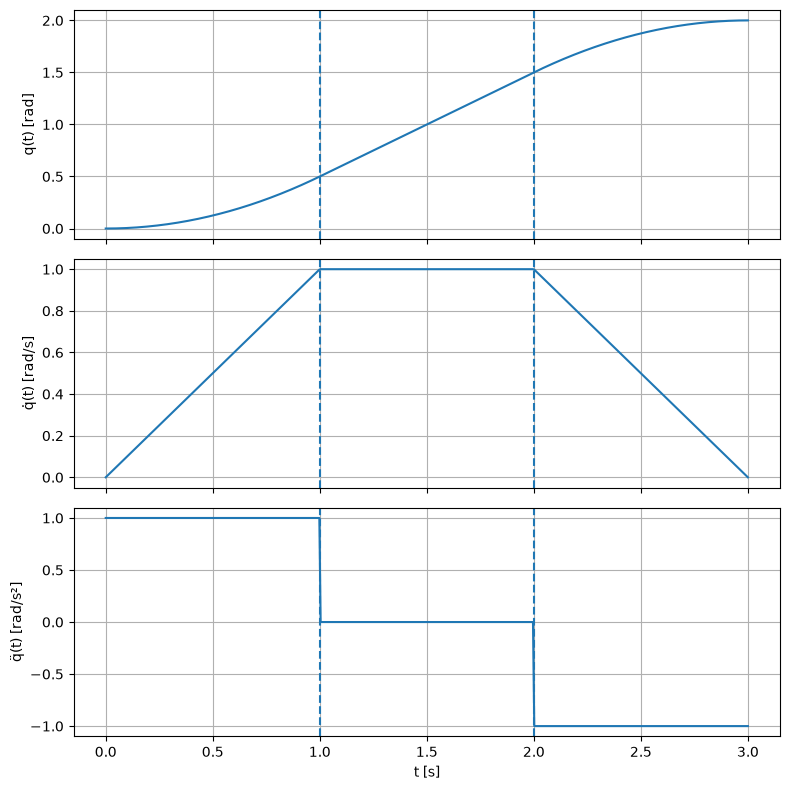

In [2]:
import numpy as np
import matplotlib.pyplot as plt

tf = 3.0
tc = 1.0
qf = 2.0
a = 1.0

t = np.linspace(0, tf, 500)

q = np.zeros_like(t)
q_dot = np.zeros_like(t)
q_ddot = np.zeros_like(t)

# Fase 1: aceleración
m1 = t <= tc
q[m1] = 0.5 * a * t[m1]**2
q_dot[m1] = a * t[m1]
q_ddot[m1] = a

# Fase 2: velocidad constante
m2 = (t > tc) & (t <= tf - tc)
q[m2] = t[m2] - 0.5
q_dot[m2] = 1.0
q_ddot[m2] = 0.0

# Fase 3: desaceleración
m3 = t > tf - tc
q[m3] = qf - 0.5 * a * (tf - t[m3])**2
q_dot[m3] = a * (tf - t[m3])
q_ddot[m3] = -a

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax[0].plot(t, q)
ax[0].set_ylabel("q(t) [rad]")
ax[0].grid()

ax[1].plot(t, q_dot)
ax[1].set_ylabel("q̇(t) [rad/s]")
ax[1].grid()

ax[2].plot(t, q_ddot)
ax[2].set_ylabel("q̈(t) [rad/s²]")
ax[2].set_xlabel("t [s]")
ax[2].grid()

for axy in ax:
    axy.axvline(1, linestyle="--")
    axy.axvline(2, linestyle="--")

plt.tight_layout()
plt.show()